In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np
import copy

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LassoCV

import shap

In [24]:
df = pd.read_csv('./data/var_scores.csv', index_col=None)

In [25]:
data = pd.read_csv('./data/S1_WGATAR_uq_DESeq2_with_TF.csv')
d = dict(zip(data["WGATAR_id"], data["D12vsD0_DESeq2_log2FoldChange"]))

In [26]:
tad = pd.read_csv('./data/TAD.csv')
d_tad = dict(zip(tad["WGATAR_id"], tad["Hudep2_TAD_position"]))
tad_list = list(set(tad["Hudep2_TAD_position"]))

In [27]:
df['effect'] = df['WGATAR_id'].map(d)
df['effect'] = -df['effect']
df['tad'] = df['WGATAR_id'].map(d_tad)

In [28]:
df = df.dropna(subset=['effect'])

df = df.drop(columns=['WGATAR_id'])

In [29]:
##########################

In [30]:
random_state = None
run = 50
i = 0
n = round(len(tad_list)*0.8)
import random

r_ = []
pr_ = []

In [31]:
data_list = []
while i < run:

    datas = {'y_pred_train': None,
         'y_train': None,
         'y_pred_test': None,
         'y_test': None}
    shuffled = random.sample(tad_list, k=len(tad_list))
    train = shuffled[:n]
    test = shuffled[n:]
    df_train = df[df['tad'].isin(train)]
    df_test = df[df['tad'].isin(test)]

    y_train = df_train['effect']
    X_train = df_train.drop(['effect','tad'], axis=1)
    X_train = X_train.fillna(0)

    
    y_test = df_test['effect']
    X_test = df_test.drop(['effect','tad'], axis=1)
    X_test = X_test.fillna(0)

    
    rf = RandomForestRegressor(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=1,
        max_features=1,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    # Predict and evaluate
    y_pred = rf.predict(X_test)

    s =  spearmanr(y_test, y_pred)
    p = pearsonr(y_test, y_pred)

    if s[0] > 0.28:

        y_pred_train = rf.predict(X_train)  
        datas['y_pred_train'] = copy.deepcopy(y_pred_train)
        datas['y_train'] = copy.deepcopy(y_train)
        datas['y_pred_test'] = copy.deepcopy(y_pred)
        datas['y_test'] = copy.deepcopy(y_test)
        data_list.append(copy.deepcopy(datas))
        
    if (s[0] > 0) and p[0] > 0:
        r_.append(s[0])
        pr_.append(p[0])
        i += 1

/lsf_tmp/287119223.tmpdir/ipykernel_4072555/2046227091.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pr_, r_],


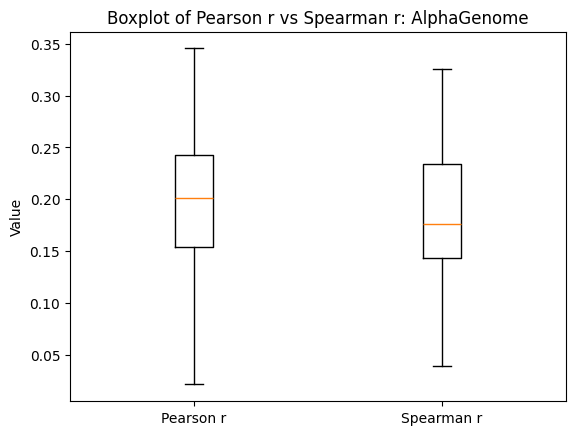

In [32]:
plt.boxplot([pr_, r_],
            labels=['Pearson r', 'Spearman r'])
plt.ylabel("Value")
plt.title("Boxplot of Pearson r vs Spearman r: AlphaGenome")
plt.savefig('correlation_alphagenome.pdf')

In [33]:
cor = pd.DataFrame({'Pearson':pr_, 'Spearman': r_})
cor.to_csv('./data/correlation_alphagenome.csv', index=None)

In [174]:
################# rf

In [175]:
datas = random.choice(data_list)

In [176]:
y_pred_train = datas['y_pred_train']
y_pred_test  = datas['y_pred_test']

y_train = datas['y_train']
y_test = datas['y_test']

In [ ]:
df_train = pd.DataFrame({'train':y_train, 'pred_train':y_pred_train})
df_train.to_csv('./data/train.csv')

In [ ]:
df_test = pd.DataFrame({'test':y_test, 'pred_test':y_pred_test})
df_test.to_csv('./data/test.csv')

In [ ]:
y_train, y_pred_train = list(df_train['train']), list(df_train['pred_train'])

y_test,  y_pred_test = list(df_test['test']), list(df_test['pred_test'])

In [182]:
y_all = y_train + y_test
y_pred_all = y_pred_train + y_pred_test
r_all, _ = spearmanr(y_all, y_pred_all)
r_test,  _  = spearmanr(y_test,  y_pred_test)

print(f"Train spearman r = {r_train:.3f} (p={p_train:.2e})")
print(f"Test  spearmanr r = {r_test:.3f} (p={p_test:.2e})")

Train spearman r = 0.885 (p=3.25e-320)
Test  spearmanr r = 0.285 (p=2.02e-05)


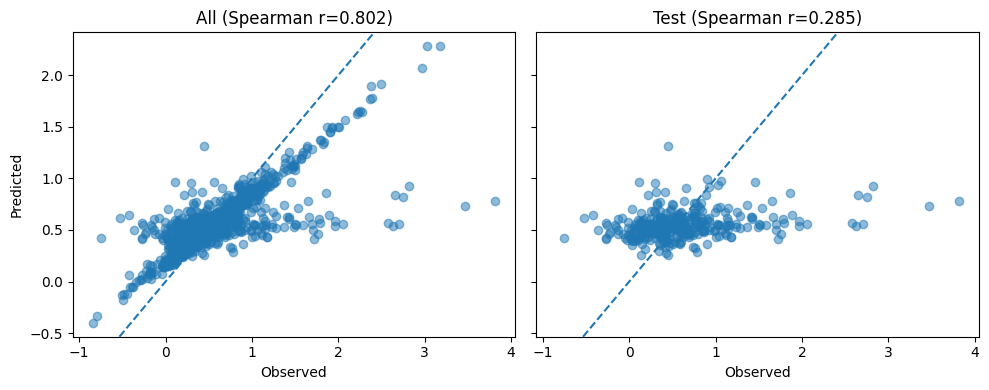

In [183]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

axes[0].scatter(y_all, y_pred_all, alpha=0.5)
axes[0].set_title(f"All (Spearman r={r_all:.3f})")
axes[0].set_xlabel("Observed")
axes[0].set_ylabel("Predicted")
axes[0].axline((0, 0), slope=1, linestyle="--")

axes[1].scatter(y_test, y_pred_test, alpha=0.5)
axes[1].set_title(f"Test (Spearman r={r_test:.3f})")
axes[1].set_xlabel("Observed")
axes[1].axline((0, 0), slope=1, linestyle="--")

plt.tight_layout()
plt.show()

In [ ]:
############## Shap

In [ ]:
def ABS_SHAP(df_shap,df, max_display=10, figsize=(8,8), plot=True):
    #import matplotlib as plt
    # Make a copy of the input data
    shap_v = pd.DataFrame(df_shap)
    feature_list = df.columns
    shap_v.columns = feature_list
    df_v = df.copy().reset_index().drop('index',axis=1)
    
    # Determine the correlation in order to plot with different colors
    corr_list = list()
    for i in feature_list:
        b = np.corrcoef(shap_v[i],df_v[i])[1][0]
        corr_list.append(b)
    corr_df = pd.concat([pd.Series(feature_list),pd.Series(corr_list)],axis=1).fillna(0)
    # Make a data frame. Column 1 is the feature, and Column 2 is the correlation coefficient
    corr_df.columns  = ['Variable','Corr']
    corr_df['Sign'] = np.where(corr_df['Corr']>0,'mediumseagreen','silver')
    
    # Plot it
    
    shap_abs = np.abs(shap_v)
    k=pd.DataFrame(shap_abs.mean()).reset_index()
    k.columns = ['Variable','SHAP_abs']
    k1 = k.merge(corr_df,left_on = 'Variable',right_on='Variable',how='inner')
    k1 = k1.sort_values(by='SHAP_abs',ascending = True)
    k2 = k1.tail(max_display)
    colorlist = k2['Sign']
    if plot:
        plt.figure(figsize=(11,11))
        sns.set(font_scale=1, style='whitegrid')
        ax = k2.plot.barh(x='Variable',y='SHAP_abs',color = colorlist, figsize=figsize,legend=False)
        ax.set_xlabel("SHAP Value (GREEN = Positive Impact)")
        plt.tight_layout()
    return k1

In [ ]:
X = df.drop(columns=["effect", 'tad'])
y = df["effect"]

In [ ]:
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=1,
    max_features=0.4,
    random_state=42,
    n_jobs=-1,
)

In [ ]:
shap_list = []
for i in range(50):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=None
    )

    label = X_test.columns
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)
    shap_values_df = pd.DataFrame(shap_values, columns = label)
    x_test_df = pd.DataFrame(X_test, columns = label)
    impact = ABS_SHAP(shap_values_df, x_test_df, plot=False)
    shap_list.append(impact)

In [ ]:
import copy
dfs = []
for f in shap_list:
    f = f.sort_values(by='Variable', ignore_index=True)
    dfs.append(copy.deepcopy(f))
for f in dfs:
    var = f['Variable']
    
cols = ['SHAP_abs', 'Corr']
stacked = np.stack([df[cols].values for df in dfs], axis=0)  # shape: (n_dfs, n_rows, n_cols)

# Compute statistics across the 0th axis (i.e., across DataFrames)
mean_df = pd.DataFrame(stacked.mean(axis=0), columns=[f"{c}_mean" for c in cols])
std_df = pd.DataFrame(stacked.std(axis=0, ddof=1), columns=[f"{c}_std" for c in cols])  # ddof=1 for sample std

# Optionally combine them
final_df = pd.concat([mean_df, std_df], axis=1)
final_df['Var'] = var

sign_color = np.where(final_df['Corr_mean'] > 0, 'mediumseagreen', 'silver')
final_df["sign"] = sign_color

final_df = final_df.sort_values(by='SHAP_abs_mean',ascending = True)
k2 = final_df.tail(15)

k2.to_csv('./data/top_15_shap_alphaGenome.csv', index=None)
final_df.to_csv('./data/all_shap_alphaGenome.csv', index=None)

In [ ]:
import seaborn as sns
figsize=(11,11)
colorlist = k2['sign']
plt.figure(figsize=(11,11))
sns.set(font_scale=1, style='whitegrid')
ax = k2.plot.barh(x='Var',y='SHAP_abs_mean',xerr='SHAP_abs_std', color = colorlist, figsize=(11,11),legend=False, capsize=5)
ax.set_xlabel("SHAP Value (GREEN = Positive Impact)")
plt.tight_layout()
plt.savefig('shap_features_alphaGenome.pdf')